First rows of dataset:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

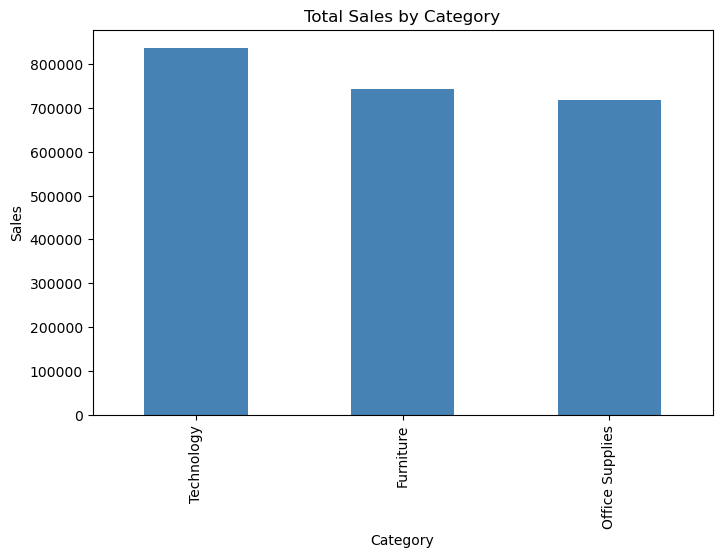

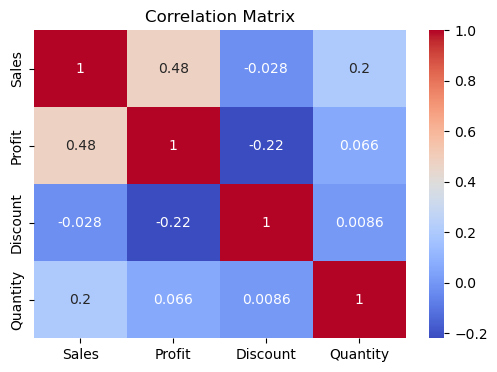

C:\Users\User\AppData\Local\Temp\ipykernel_7548\2472046667.py:80: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample("M", on="Order Date")["Sales"].sum().reset_index()


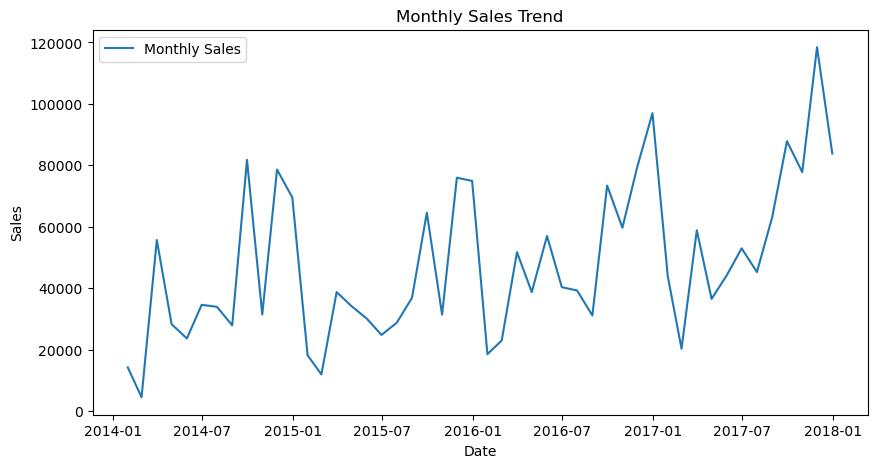


R-squared: 0.2511984575232219


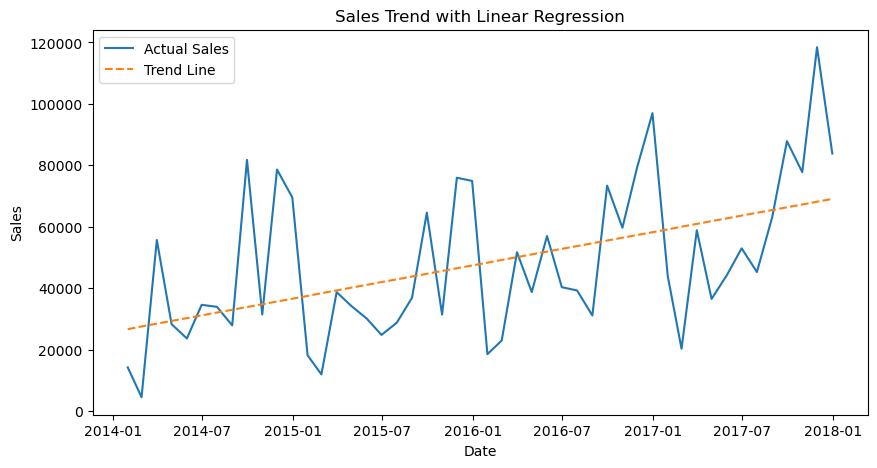

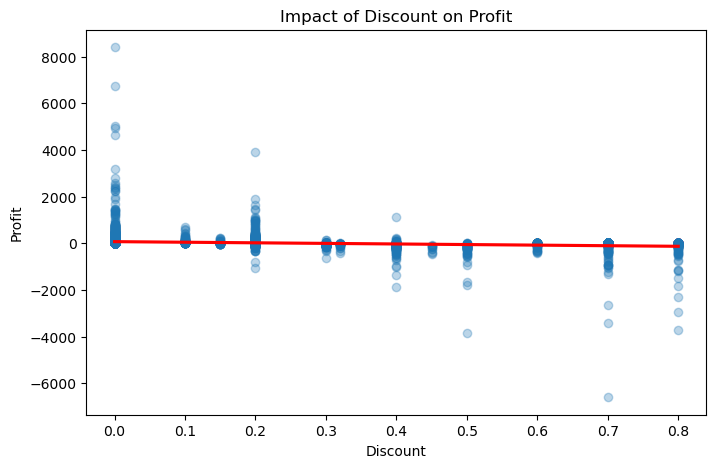

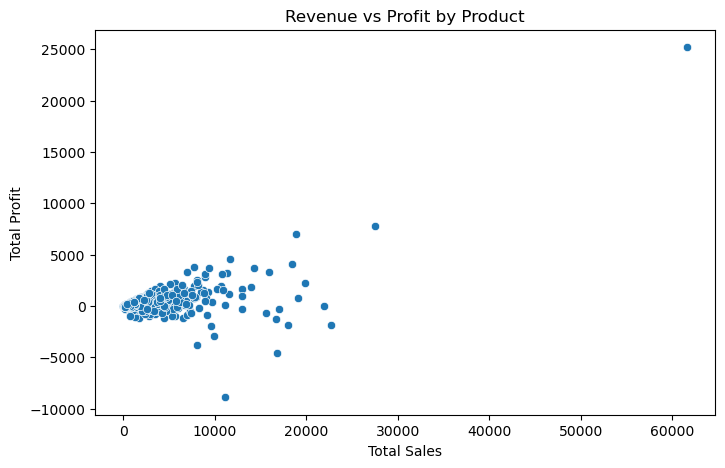

C:\Users\User\AppData\Local\Temp\ipykernel_7548\2472046667.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


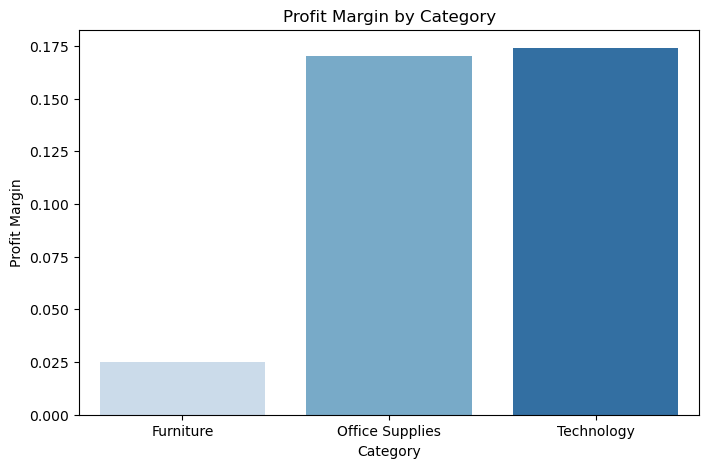


Number of orders with negative profit:
1871

Products generating the highest losses:
Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.5272
Ibico EPK-21 Electric Binding System                                          -2929.4845
Bush Advantage Collection Racetrack Conference Table                          -2545.2600
Name: Profi

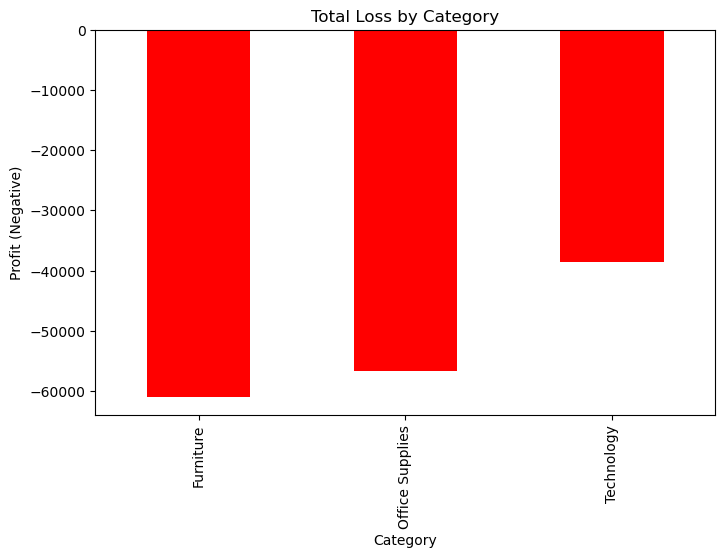

C:\Users\User\AppData\Local\Temp\ipykernel_7548\2472046667.py:228: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


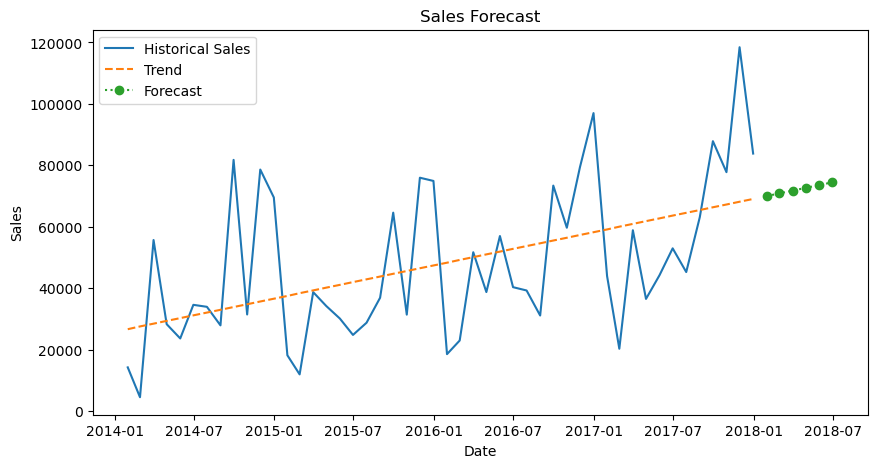


Key Business Insights:
- Sales tend to increase toward the end of the year, indicating seasonal demand.
- Technology generates the highest revenue among categories.
- Higher discounts are strongly associated with lower profitability.
- Some products generate losses due to aggressive discount strategies.
- Monitoring discount policies could significantly improve margins.
- Forecast suggests continuation of the current sales trend.


In [1]:
# -------------------------------------------------
# Superstore Sales Analysis
# -------------------------------------------------
# This notebook explores sales performance using the Superstore dataset.
# The objective is to identify trends, profitability patterns,
# and generate business insights.

# -------------------------------------------------
# Import libraries
# -------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Load dataset
# -------------------------------------------------

df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Preview dataset
print("First rows of dataset:")
print(df.head())

# -------------------------------------------------
# Dataset structure
# -------------------------------------------------

print("\nDataset information:")
print(df.info())

# -------------------------------------------------
# Summary statistics
# -------------------------------------------------

print("\nSummary statistics:")
print(df.describe())

print("\nSummary including categorical variables:")
print(df.describe(include="all"))

# -------------------------------------------------
# Exploratory Data Analysis
# -------------------------------------------------

sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_by_category.plot(kind="bar", color="steelblue")

plt.title("Total Sales by Category")
plt.ylabel("Sales")

plt.show()

# -------------------------------------------------
# Correlation analysis
# -------------------------------------------------

corr = df[["Sales","Profit","Discount","Quantity"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# -------------------------------------------------
# Sales trend analysis
# -------------------------------------------------

monthly_sales = df.resample("M", on="Order Date")["Sales"].sum().reset_index()

monthly_sales = monthly_sales.sort_values("Order Date")

plt.figure(figsize=(10,5))

plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], label="Monthly Sales")

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()

# -------------------------------------------------
# Linear regression trend
# -------------------------------------------------

X = np.arange(len(monthly_sales)).reshape(-1,1)
y = monthly_sales["Sales"].values

model = LinearRegression()
model.fit(X, y)

trend = model.predict(X)

r2 = model.score(X, y)

print("\nR-squared:", r2)

plt.figure(figsize=(10,5))

plt.plot(monthly_sales["Order Date"], y, label="Actual Sales")
plt.plot(monthly_sales["Order Date"], trend, linestyle="--", label="Trend Line")

plt.title("Sales Trend with Linear Regression")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()

# -------------------------------------------------
# Impact of Discount on Profit
# -------------------------------------------------

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

# -------------------------------------------------
# Revenue vs Profit by Product
# -------------------------------------------------

product_analysis = df.groupby("Product Name").agg({
    "Sales":"sum",
    "Profit":"sum"
}).reset_index()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=product_analysis,
    x="Sales",
    y="Profit"
)

plt.title("Revenue vs Profit by Product")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.show()

# -------------------------------------------------
# Profit Margin by Category
# -------------------------------------------------

category_analysis = df.groupby("Category").agg({
    "Sales":"sum",
    "Profit":"sum"
}).reset_index()

category_analysis["Profit Margin"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Profit Margin",
    palette="Blues"
)

plt.title("Profit Margin by Category")
plt.ylabel("Profit Margin")

plt.show()

# -------------------------------------------------
# Orders with Negative Profit
# -------------------------------------------------

negative_profit_orders = df[df["Profit"] < 0]

print("\nNumber of orders with negative profit:")
print(len(negative_profit_orders))

loss_products = negative_profit_orders.groupby("Product Name")["Profit"].sum().sort_values()

print("\nProducts generating the highest losses:")
print(loss_products.head(10))

loss_by_category = negative_profit_orders.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))

loss_by_category.plot(kind="bar", color="red")

plt.title("Total Loss by Category")
plt.ylabel("Profit (Negative)")

plt.show()

# -------------------------------------------------
# Sales Forecast
# -------------------------------------------------

forecast_periods = 6

future_X = np.arange(len(monthly_sales), len(monthly_sales) + forecast_periods).reshape(-1,1)

forecast = model.predict(future_X)

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.DateOffset(months=1),
    periods=forecast_periods,
    freq="M"
)

forecast_df = pd.DataFrame({
    "Order Date": future_dates,
    "Forecast Sales": forecast
})

plt.figure(figsize=(10,5))

plt.plot(monthly_sales["Order Date"], y, label="Historical Sales")
plt.plot(monthly_sales["Order Date"], trend, linestyle="--", label="Trend")

plt.plot(
    forecast_df["Order Date"],
    forecast_df["Forecast Sales"],
    linestyle=":",
    marker="o",
    label="Forecast"
)

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()

# -------------------------------------------------
# Business Insights
# -------------------------------------------------

print("\nKey Business Insights:")

print("- Sales tend to increase toward the end of the year, indicating seasonal demand.")
print("- Technology generates the highest revenue among categories.")
print("- Higher discounts are strongly associated with lower profitability.")
print("- Some products generate losses due to aggressive discount strategies.")
print("- Monitoring discount policies could significantly improve margins.")
print("- Forecast suggests continuation of the current sales trend.")
